In [36]:
print('hi')

hi


In [37]:
import numpy as np
import networkx as nx
import pandas as pd
import random
from collections import Counter, defaultdict

In [38]:
np.random.seed(42)
random.seed(42)

# --- SBM parameters ---
num_blocks = 3
block_size = 50
n = num_blocks * block_size

# block membership
labels = np.repeat(np.arange(num_blocks), block_size)

# high homophily: strong within-block, weak between-block
p_in = 0.8
p_out = 0.2

P = np.full((num_blocks, num_blocks), p_out)
np.fill_diagonal(P, p_in)

# --- generate SBM adjacency matrix ---
A = np.zeros((n, n))

for i in range(n):
    for j in range(i+1, n):
        pi = P[labels[i], labels[j]]
        if np.random.rand() < pi:
            A[i, j] = 1
            A[j, i] = 1

G = nx.from_numpy_array(A)

print(A.shape)

(150, 150)


In [39]:
df = pd.DataFrame({
    "node_id": np.arange(n),
    "block": labels
})

df["degree"] = dict(G.degree()).values()

In [40]:
opinions_all = [1, 2, 3, 4]

# 1. assign a dominant opinion to each block
block_dominant = {
    b: np.random.choice(opinions_all)
    for b in range(num_blocks)
}

opinions = []

correlation = 0.8

for i in range(n):
    b = df.loc[i, "block"]
    dominant = block_dominant[b]

    # build probability vector
    probs = np.full(4, (1 - correlation) / 3)  # 3 non-dominant opinions
    probs[dominant - 1] = correlation    # index shift (opinions are 1–4)

    # sample
    opinions.append(np.random.choice(opinions_all, p=probs))

df["opinion"] = opinions

In [41]:
print(df)

     node_id  block  degree  opinion
0          0      0      64        4
1          1      0      59        4
2          2      0      68        3
3          3      0      52        4
4          4      0      67        3
..       ...    ...     ...      ...
145      145      2      68        1
146      146      2      59        3
147      147      2      71        1
148      148      2      54        3
149      149      2      67        3

[150 rows x 4 columns]


In [42]:
# perform rds on the graph given
def rds_with_tracking(G, seeds, sample_size=50, max_recruits=2):
    import random
    
    sampled = set(seeds)
    queue = [(s, 0) for s in seeds]  # (node, wave)
    
    records = []
    
    # initialize seeds
    for s in seeds:
        records.append({
            "node_id": s,
            "recruiter": None,
            "wave": 0
        })
    
    referrer_to_recruits = defaultdict(list)
    
    while queue and len(sampled) < sample_size:
        node, wave = queue.pop(0)
        
        neighbors = list(G.neighbors(node))
        random.shuffle(neighbors)
        
        recruits = 0
        
        for nb in neighbors:
            if nb not in sampled:
                sampled.add(nb)
                
                records.append({
                    "node_id": nb,
                    "recruiter": node,
                    "wave": wave + 1
                })

                referrer_to_recruits[node].append(nb)
                
                queue.append((nb, wave + 1))
                
                recruits += 1
                if recruits >= max_recruits or len(sampled) >= sample_size:
                    break
    
    return pd.DataFrame(records), referrer_to_recruits

seeds = random.sample(range(n), 5)

rds_df, referrer_to_recruits = rds_with_tracking(G, seeds, sample_size=30, max_recruits=2)

rds_df = rds_df.merge(df[["node_id", "opinion", "degree", "block"]], on="node_id", how="left")
print(rds_df)

    node_id  recruiter  wave  opinion  degree  block
0        28        NaN     0        1      56      0
1         6        NaN     0        4      61      0
2        70        NaN     0        4      61      1
3        62        NaN     0        1      60      1
4        57        NaN     0        1      61      1
5        46       28.0     1        4      53      0
6        25       28.0     1        4      60      0
7        12        6.0     1        4      58      0
8         0        6.0     1        4      64      0
9         9       70.0     1        4      58      0
10       80       70.0     1        1      71      1
11      148       62.0     1        3      54      2
12      136       62.0     1        1      64      2
13       87       57.0     1        1      54      1
14       15       57.0     1        4      59      0
15       31       46.0     2        2      59      0
16       32       46.0     2        4      66      0
17       33       25.0     2        4      61 

In [43]:
print(referrer_to_recruits)

defaultdict(<class 'list'>, {28: [46, 25], 6: [12, 0], 70: [9, 80], 62: [148, 136], 57: [87, 15], 46: [31, 32], 25: [33, 14], 12: [42, 71], 0: [45, 20], 9: [116, 118], 80: [88, 65], 148: [130, 145], 136: [146]})


In [44]:
def vh_estimator(rds_df):
    weights = 1 / rds_df["degree"]
    
    weighted_counts = (
        rds_df
        .assign(weight=weights)
        .groupby("opinion")["weight"]
        .sum()
    )

    return (weighted_counts / weighted_counts.sum()).sort_index()

def get_distribution(series):
    return series.value_counts(normalize=True).sort_index()


def total_variation(p, q):
    idx = sorted(set(p.index).union(q.index))
    p = p.reindex(idx, fill_value=0)
    q = q.reindex(idx, fill_value=0)
    return 0.5 * np.abs(p - q).sum()


def kl_divergence(p_true, p_est, eps=1e-12):
    """KL(true || est): information lost when est is used to encode true.
    Small eps avoids -inf when an opinion is missing from the estimator."""
    idx = sorted(set(p_true.index).union(p_est.index))
    p = p_true.reindex(idx, fill_value=0).values.astype(float) + eps
    q = p_est.reindex(idx, fill_value=0).values.astype(float) + eps
    p = p / p.sum()
    q = q / q.sum()
    return float(np.sum(p * np.log(p / q)))

In [45]:
recruiter_map = {}

for r, recruits in referrer_to_recruits.items():
    for u in recruits:
        recruiter_map[u] = r

In [47]:
def vh_with_homophily_adjustment(rds_df, recruiter_map, alpha=0.5):
    weights = []
    
    for _, row in rds_df.iterrows():
        node = row["node_id"]
        base_weight = 1 / row["degree"]
        
        recruiter = recruiter_map.get(node, None)
        
        if recruiter is None:
            weights.append(base_weight)  # seed
            continue
        
        # compare blocks
        if df.loc[node, "block"] == df.loc[recruiter, "block"]:
            weights.append(alpha * base_weight)
        else:
            weights.append(base_weight)
    
    rds_df = rds_df.copy()
    rds_df["weight"] = weights
    
    weighted_counts = (
        rds_df
        .groupby("opinion")["weight"]
        .sum()
    )
    
    return (weighted_counts / weighted_counts.sum()).sort_index()

def compute_alpha(correlation, SBM_p):
    k = 1 / (1 - SBM_p)
    return 1 / (1 + (k - 1) * correlation)

sample_dist = get_distribution(rds_df["opinion"])
vh_dist = vh_estimator(rds_df)
alpha = compute_alpha(correlation=correlation, SBM_p=p_in)  # Example values
adj_dist = vh_with_homophily_adjustment(rds_df, recruiter_map, alpha=alpha)
pop_dist = get_distribution(df["opinion"])

print("Sample distribution:\n", sample_dist, "\n")
print("Adjusted VH estimate:\n", adj_dist, "\n")
print("True population distribution:\n", pop_dist, "\n")

print("KL (sample vs population):", kl_divergence(sample_dist, pop_dist))
print("KL (VH vs population):", kl_divergence(vh_dist, pop_dist))
print("KL (Adjusted vs population):", kl_divergence(adj_dist, pop_dist))

Sample distribution:
 opinion
1    0.333333
2    0.066667
3    0.133333
4    0.466667
Name: proportion, dtype: float64 

Adjusted VH estimate:
 opinion
1    0.371873
2    0.027878
3    0.210351
4    0.389898
Name: weight, dtype: float64 

True population distribution:
 opinion
1    0.346667
2    0.060000
3    0.300000
4    0.293333
Name: proportion, dtype: float64 

KL (sample vs population): 0.10250238495763124
KL (VH vs population): 0.09871274062678026
KL (Adjusted vs population): 0.04101230375963914


## Parameter sweep — finding the best homophily-adjustment alpha

For each configuration (varying SBM density, homophily, opinion concentration, RDS sample size, etc.) we run `n_trials` Monte Carlo replications. Each trial generates a fresh graph + fresh RDS sample, and we sweep `alpha ∈ [0, 1]` reusing the same sample within the trial. We then average TV distance across trials, pick the alpha that minimizes mean TV per config, and regress that best alpha on the configuration features.

In [90]:
def build_sbm(num_blocks, block_size, p_in, p_out, rng):
    n = num_blocks * block_size
    block_labels = np.repeat(np.arange(num_blocks), block_size)

    P = np.full((num_blocks, num_blocks), p_out)
    np.fill_diagonal(P, p_in)
    prob_matrix = P[block_labels][:, block_labels]

    upper = np.triu(rng.random((n, n)) < prob_matrix, k=1)
    A = (upper | upper.T).astype(int)
    G = nx.from_numpy_array(A)

    nodes_df = pd.DataFrame({
        "node_id": np.arange(n),
        "block": block_labels,
        "degree": A.sum(axis=1),
    })
    return G, nodes_df


def assign_block_opinions(nodes_df, num_blocks, concentration, rng, num_opinions=4):
    """concentration = probability mass placed on each block's dominant opinion."""
    block_dominant = {b: int(rng.integers(1, num_opinions + 1)) for b in range(num_blocks)}
    rest = (1 - concentration) / (num_opinions - 1)

    opinions = np.empty(len(nodes_df), dtype=int)
    for i, b in enumerate(nodes_df["block"].values):
        probs = np.full(num_opinions, rest)
        probs[block_dominant[b] - 1] = concentration
        opinions[i] = rng.choice(np.arange(1, num_opinions + 1), p=probs)

    nodes_df = nodes_df.copy()
    nodes_df["opinion"] = opinions
    return nodes_df


def run_rds_trial(G, n, num_seeds, sample_size, max_recruits, rng):
    # only seed from non-isolated nodes — otherwise 1/degree = inf and that
    # seed dominates the renormalization, silently poisoning the trial.
    nonisolated = np.array([v for v in range(n) if G.degree(v) > 0])
    k = min(num_seeds, len(nonisolated))
    seeds = rng.choice(nonisolated, size=k, replace=False).tolist()

    sampled = set(seeds)
    queue = [(s, 0) for s in seeds]
    records = [{"node_id": s, "recruiter": None, "wave": 0} for s in seeds]
    referrer_to_recruits = defaultdict(list)

    while queue and len(sampled) < sample_size:
        node, wave = queue.pop(0)
        neighbors = list(G.neighbors(node))
        rng.shuffle(neighbors)

        recruits = 0
        for nb in neighbors:
            if nb in sampled:
                continue
            sampled.add(nb)
            records.append({"node_id": nb, "recruiter": node, "wave": wave + 1})
            referrer_to_recruits[node].append(nb)
            queue.append((nb, wave + 1))
            recruits += 1
            if recruits >= max_recruits or len(sampled) >= sample_size:
                break

    return pd.DataFrame(records), referrer_to_recruits

In [91]:
def precompute_homophily_weights(rds_df, nodes_df, recruiter_map):
    """Precompute base weights (1/degree) and the homophilic-edge mask once per
    trial, so the alpha sweep is just a vectorized reweight + renormalize."""
    block_lookup = nodes_df.set_index("node_id")["block"].to_dict()

    base_weights = 1.0 / rds_df["degree"].values
    is_homophilic = np.zeros(len(rds_df), dtype=bool)
    for i, node in enumerate(rds_df["node_id"].values):
        recruiter = recruiter_map.get(node)
        if recruiter is not None and block_lookup[node] == block_lookup[recruiter]:
            is_homophilic[i] = True

    return base_weights, is_homophilic


def adjusted_dist_from_alpha(opinions, base_weights, is_homophilic, alpha):
    """Reweight: homophilic recruits scaled by alpha, then renormalize."""
    weights = base_weights * np.where(is_homophilic, alpha, 1.0)
    counts = pd.DataFrame({"opinion": opinions, "w": weights}).groupby("opinion")["w"].sum()
    return (counts / counts.sum()).sort_index()

In [92]:
def run_one_trial(config, alphas, rng):
    G, nodes_df = build_sbm(
        config["num_blocks"], config["block_size"],
        config["p_in"], config["p_out"], rng,
    )
    nodes_df = assign_block_opinions(
        nodes_df, config["num_blocks"], config["concentration"], rng,
    )
    n = config["num_blocks"] * config["block_size"]

    rds_df, referrer_to_recruits = run_rds_trial(
        G, n, config["num_seeds"], config["sample_size"],
        config["max_recruits"], rng,
    )
    rds_df = rds_df.merge(
        nodes_df[["node_id", "opinion", "degree", "block"]],
        on="node_id", how="left",
    )
    recruiter_map = {u: r for r, recs in referrer_to_recruits.items() for u in recs}

    pop_dist    = get_distribution(nodes_df["opinion"])
    sample_dist = get_distribution(rds_df["opinion"])
    vh_dist     = vh_estimator(rds_df)

    tv_naive = total_variation(sample_dist, pop_dist)
    tv_vh    = total_variation(vh_dist,     pop_dist)
    kl_naive = kl_divergence(pop_dist, sample_dist)
    kl_vh    = kl_divergence(pop_dist, vh_dist)

    base_weights, is_homophilic = precompute_homophily_weights(rds_df, nodes_df, recruiter_map)
    opinions = rds_df["opinion"].values

    rows = []
    for alpha in alphas:
        adj_dist = adjusted_dist_from_alpha(opinions, base_weights, is_homophilic, alpha)
        rows.append({
            "alpha":           float(alpha),
            "tv_adjusted":     total_variation(adj_dist, pop_dist),
            "tv_vh":           tv_vh,
            "tv_naive":        tv_naive,
            "kl_adjusted":     kl_divergence(pop_dist, adj_dist),
            "kl_vh":           kl_vh,
            "kl_naive":        kl_naive,
            "frac_homophilic": float(is_homophilic.mean()),
        })
    return pd.DataFrame(rows)

In [93]:
import itertools

p_in_values        = [0.4, 0.6, 0.8]
p_out_values       = [0.05, 0.15]
num_blocks_values  = [5, 10]
block_size_values  = [10, 20, 30]
# key value in our tradeoff between penalizing internal edges and not
concentration_vals = [0.4, 0.6, 0.8]
sample_size_vals   = [30, 50]
max_recruits       = 2
num_seeds          = 5

configs = []
for p_in, p_out, nb, bs, conc, ss in itertools.product(
    p_in_values, p_out_values, num_blocks_values, block_size_values,
    concentration_vals, sample_size_vals,
):
    if p_in <= p_out:
        continue
    configs.append({
        "p_in": p_in,
        "p_out": p_out,
        "num_blocks": nb,
        "block_size": bs,
        "concentration": conc,
        "sample_size": ss,
        "max_recruits": max_recruits,
        "num_seeds": num_seeds,
    })

print(f"{len(configs)} configurations")

216 configurations


In [94]:
alphas   = np.linspace(0.0, 1.0, 21)
n_trials = 30

records = []
for cfg_id, cfg in enumerate(configs):
    for trial in range(n_trials):
        rng = np.random.default_rng(seed=10_000 * cfg_id + trial)
        trial_df = run_one_trial(cfg, alphas, rng)
        trial_df["config_id"] = cfg_id
        trial_df["trial"] = trial
        records.append(trial_df)
    if (cfg_id + 1) % 10 == 0 or cfg_id == len(configs) - 1:
        print(f"  done: {cfg_id + 1}/{len(configs)} configs")

results = pd.concat(records, ignore_index=True)
config_df = pd.DataFrame(configs).reset_index().rename(columns={"index": "config_id"})
results = results.merge(config_df, on="config_id")
print("results shape:", results.shape)
results.head()

  done: 10/216 configs
  done: 20/216 configs
  done: 30/216 configs
  done: 40/216 configs
  done: 50/216 configs
  done: 60/216 configs
  done: 70/216 configs
  done: 80/216 configs
  done: 90/216 configs
  done: 100/216 configs
  done: 110/216 configs
  done: 120/216 configs
  done: 130/216 configs
  done: 140/216 configs
  done: 150/216 configs
  done: 160/216 configs
  done: 170/216 configs
  done: 180/216 configs
  done: 190/216 configs
  done: 200/216 configs
  done: 210/216 configs
  done: 216/216 configs
results shape: (136080, 18)


,alpha,tv_adjusted,tv_vh,tv_naive,kl_adjusted,kl_vh,kl_naive,frac_homophilic,config_id,trial,p_in,p_out,num_blocks,block_size,concentration,sample_size,max_recruits,num_seeds
0,0.00,0.238439,0.164474,0.093333,0.134710,0.062055,0.029953,0.533333,0,0,0.4,0.05,5,10,0.4,30,2,5
1,0.05,0.230876,0.164474,0.093333,0.122640,0.062055,0.029953,0.533333,0,0,0.4,0.05,5,10,0.4,30,2,5
2,0.10,0.224102,0.164474,0.093333,0.112944,0.062055,0.029953,0.533333,0,0,0.4,0.05,5,10,0.4,30,2,5
3,0.15,0.217999,0.164474,0.093333,0.105034,0.062055,0.029953,0.533333,0,0,0.4,0.05,5,10,0.4,30,2,5
4,0.20,0.212472,0.164474,0.093333,0.098494,0.062055,0.029953,0.533333,0,0,0.4,0.05,5,10,0.4,30,2,5


In [95]:
metric_cols = ["tv_adjusted", "tv_vh", "tv_naive", "kl_adjusted", "kl_vh", "kl_naive"]
agg = (
    results
    .groupby(["config_id", "alpha"], as_index=False)[metric_cols]
    .mean()
)

# best alpha selected by TV (primary), and also by KL for cross-checking
best_idx_tv     = agg.groupby("config_id")["tv_adjusted"].idxmin()
best_per_config = (
    agg.loc[best_idx_tv]
    .reset_index(drop=True)
    .rename(columns={"alpha": "best_alpha"})
    .merge(config_df, on="config_id")
)

best_alpha_kl = (
    agg.loc[agg.groupby("config_id")["kl_adjusted"].idxmin(), ["config_id", "alpha"]]
    .rename(columns={"alpha": "best_alpha_kl"})
    .reset_index(drop=True)
)
best_per_config = best_per_config.merge(best_alpha_kl, on="config_id")

best_per_config["tv_improvement_vs_vh"] = best_per_config["tv_vh"] - best_per_config["tv_adjusted"]
best_per_config["kl_improvement_vs_vh"] = best_per_config["kl_vh"] - best_per_config["kl_adjusted"]

print(best_per_config.head())
print("\nbest_alpha (TV) distribution:")
print(best_per_config["best_alpha"].describe())
print("\nbest_alpha (KL) distribution:")
print(best_per_config["best_alpha_kl"].describe())
print(f"\nmean TV reduction (VH − adjusted): {best_per_config['tv_improvement_vs_vh'].mean():.5f}")
print(f"mean KL reduction (VH − adjusted): {best_per_config['kl_improvement_vs_vh'].mean():.5f}")
print(f"\ncorrelation between TV-best and KL-best alphas: "
      f"{best_per_config[['best_alpha', 'best_alpha_kl']].corr().iloc[0, 1]:.3f}")

   config_id  best_alpha  tv_adjusted     tv_vh  tv_naive  kl_adjusted  \
0          0        0.85     0.108952  0.109837  0.081556     0.038461   
1          1        1.00     0.052555  0.052555  0.004558     0.008944   
2          2        0.90     0.094155  0.094462  0.078667     0.062147   
3          3        0.80     0.048181  0.049566  0.001143     0.008090   
4          4        0.50     0.110705  0.116496  0.101556     0.135113   

      kl_vh  kl_naive  p_in  p_out  num_blocks  block_size  concentration  \
0  0.037660  0.023311   0.4   0.05           5          10            0.4   
1  0.008944  0.000208   0.4   0.05           5          10            0.4   
2  0.062825  0.053852   0.4   0.05           5          10            0.6   
3  0.008373  0.000027   0.4   0.05           5          10            0.6   
4  0.141213  0.127681   0.4   0.05           5          10            0.8   

   sample_size  max_recruits  num_seeds  best_alpha_kl  tv_improvement_vs_vh  \
0           

In [96]:
import statsmodels.api as sm

reg_df = best_per_config.copy()
reg_df["homophily_gap"] = reg_df["p_in"] - reg_df["p_out"]

features = ["homophily_gap", "concentration", "num_blocks", "sample_size"]
X = sm.add_constant(reg_df[features])
y = reg_df["best_alpha"]

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             best_alpha   R-squared:                       0.479
Model:                            OLS   Adj. R-squared:                  0.469
Method:                 Least Squares   F-statistic:                     48.45
Date:                Thu, 30 Apr 2026   Prob (F-statistic):           7.24e-29
Time:                        21:41:31   Log-Likelihood:                 89.859
No. Observations:                 216   AIC:                            -169.7
Df Residuals:                     211   BIC:                            -152.8
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             1.4132      0.076     18.549

=== boundary positions of best alpha ===
  best_alpha >= 0.95: 57/216    best_alpha <= 0.05: 0/216
  best_alpha_kl >= 0.95: 60/216    best_alpha_kl <= 0.05: 0/216

=== how often each estimator wins (TV) ===
VH beats naive:           37/216
adjusted beats naive:     95/216
adjusted beats plain VH:  172/216

=== how often each estimator wins (KL) ===
VH beats naive:           25/216
adjusted beats naive:     64/216
adjusted beats plain VH:  144/216

=== top 5 configs where adjustment helps most (by TV improvement) ===
 config_id  best_alpha  best_alpha_kl  tv_adjusted    tv_vh  tv_naive  kl_adjusted    kl_vh  kl_naive  p_in  p_out  concentration  sample_size  tv_improvement_vs_vh  kl_improvement_vs_vh
        76        0.40           0.40     0.108638 0.125546  0.104667     0.080018 0.095735  0.080244   0.6   0.05            0.8           30              0.016907              0.015717
       155        0.35           0.45     0.098066 0.113287  0.113667     0.042896 0.049530  0.049907   

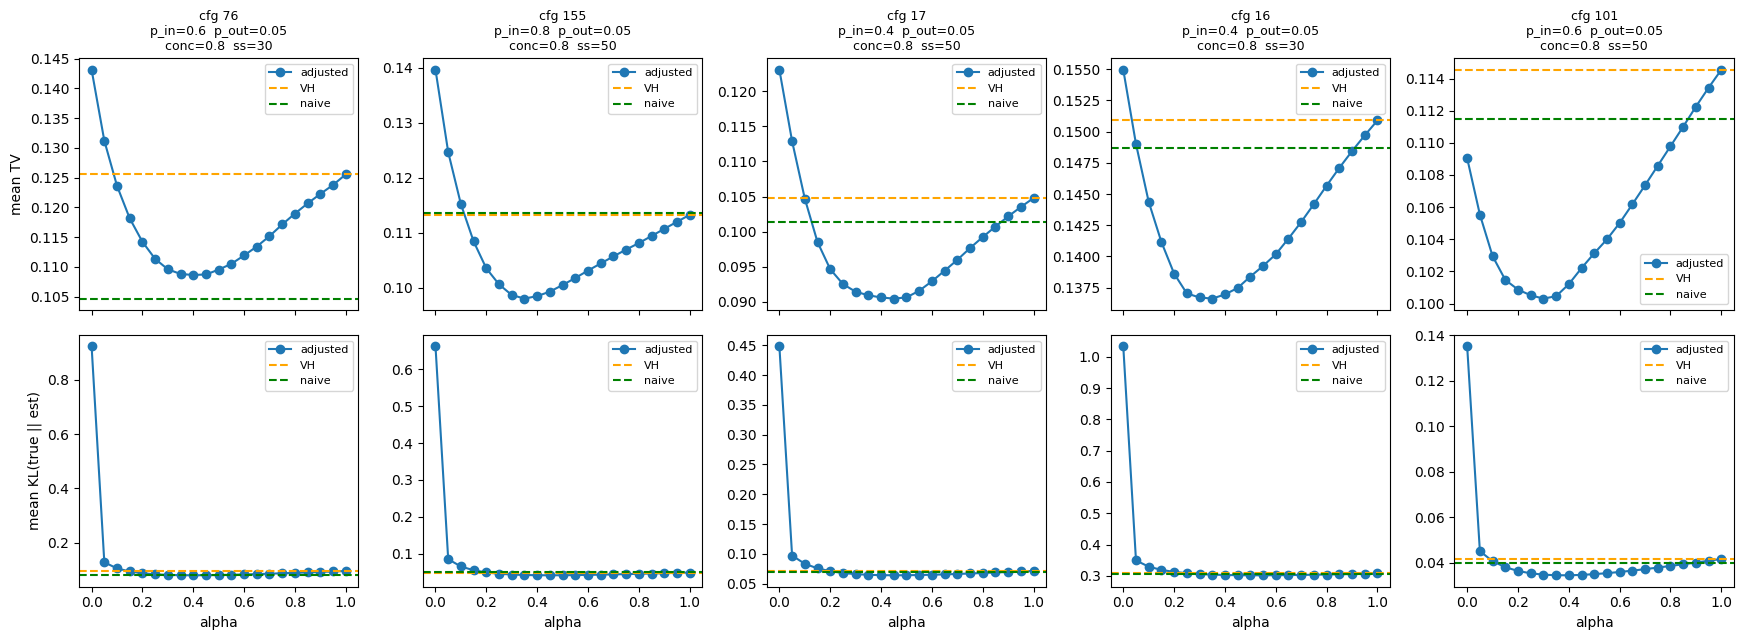

In [97]:
import matplotlib.pyplot as plt

n_total = len(best_per_config)

print("=== boundary positions of best alpha ===")
for col in ["best_alpha", "best_alpha_kl"]:
    n_at_one  = (best_per_config[col] >= 0.95).sum()
    n_at_zero = (best_per_config[col] <= 0.05).sum()
    print(f"  {col} >= 0.95: {n_at_one}/{n_total}    {col} <= 0.05: {n_at_zero}/{n_total}")

print("\n=== how often each estimator wins (TV) ===")
print(f"VH beats naive:           {(best_per_config['tv_vh']       < best_per_config['tv_naive']).sum()}/{n_total}")
print(f"adjusted beats naive:     {(best_per_config['tv_adjusted'] < best_per_config['tv_naive']).sum()}/{n_total}")
print(f"adjusted beats plain VH:  {(best_per_config['tv_adjusted'] < best_per_config['tv_vh']).sum()}/{n_total}")

print("\n=== how often each estimator wins (KL) ===")
print(f"VH beats naive:           {(best_per_config['kl_vh']       < best_per_config['kl_naive']).sum()}/{n_total}")
print(f"adjusted beats naive:     {(best_per_config['kl_adjusted'] < best_per_config['kl_naive']).sum()}/{n_total}")
print(f"adjusted beats plain VH:  {(best_per_config['kl_adjusted'] < best_per_config['kl_vh']).sum()}/{n_total}")

print("\n=== top 5 configs where adjustment helps most (by TV improvement) ===")
top = best_per_config.nlargest(5, "tv_improvement_vs_vh")[
    ["config_id", "best_alpha", "best_alpha_kl",
     "tv_adjusted", "tv_vh", "tv_naive",
     "kl_adjusted", "kl_vh", "kl_naive",
     "p_in", "p_out", "concentration", "sample_size",
     "tv_improvement_vs_vh", "kl_improvement_vs_vh"]
]
print(top.to_string(index=False))

# plot TV-vs-alpha (top row) and KL-vs-alpha (bottom row) for the top configs
top_ids = top["config_id"].tolist()
fig, axes = plt.subplots(2, len(top_ids), figsize=(3.5 * len(top_ids), 6.5), sharex=True)
for col, cid in enumerate(top_ids):
    sub = agg[agg["config_id"] == cid].sort_values("alpha")
    cfg = configs[cid]
    title = (f"cfg {cid}\np_in={cfg['p_in']}  p_out={cfg['p_out']}\n"
             f"conc={cfg['concentration']}  ss={cfg['sample_size']}")

    ax_tv = axes[0, col]
    ax_tv.plot(sub["alpha"], sub["tv_adjusted"], marker="o", label="adjusted")
    ax_tv.axhline(sub["tv_vh"].iloc[0],    color="orange", linestyle="--", label="VH")
    ax_tv.axhline(sub["tv_naive"].iloc[0], color="green",  linestyle="--", label="naive")
    ax_tv.set_title(title, fontsize=9)
    ax_tv.legend(fontsize=8)

    ax_kl = axes[1, col]
    ax_kl.plot(sub["alpha"], sub["kl_adjusted"], marker="o", label="adjusted")
    ax_kl.axhline(sub["kl_vh"].iloc[0],    color="orange", linestyle="--", label="VH")
    ax_kl.axhline(sub["kl_naive"].iloc[0], color="green",  linestyle="--", label="naive")
    ax_kl.set_xlabel("alpha")
    ax_kl.legend(fontsize=8)

axes[0, 0].set_ylabel("mean TV")
axes[1, 0].set_ylabel("mean KL(true || est)")
plt.tight_layout()
plt.show()

 alpha  tv_adjusted    tv_vh  tv_naive  kl_adjusted    kl_vh  kl_naive  frac_homophilic
  0.00     0.233592 0.074012     0.075     0.182056 0.021636  0.018512             0.52
  0.05     0.214566 0.074012     0.075     0.137964 0.021636  0.018512             0.52
  0.10     0.197539 0.074012     0.075     0.108323 0.021636  0.018512             0.52
  0.15     0.182210 0.074012     0.075     0.087294 0.021636  0.018512             0.52
  0.20     0.168337 0.074012     0.075     0.071843 0.021636  0.018512             0.52
  0.25     0.155724 0.074012     0.075     0.060215 0.021636  0.018512             0.52
  0.30     0.144204 0.074012     0.075     0.051315 0.021636  0.018512             0.52
  0.35     0.133643 0.074012     0.075     0.044420 0.021636  0.018512             0.52
  0.40     0.123925 0.074012     0.075     0.039037 0.021636  0.018512             0.52
  0.45     0.114954 0.074012     0.075     0.034813 0.021636  0.018512             0.52
  0.50     0.106645 0.074012    

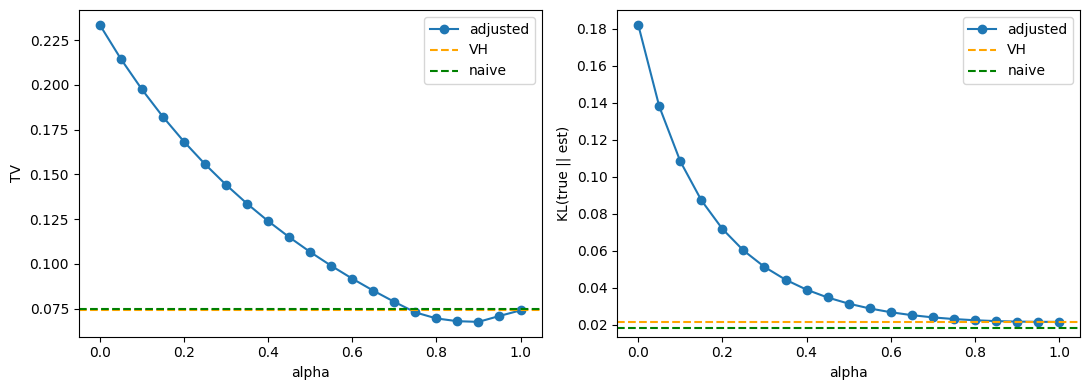

In [98]:
# manual single-config test: run one trial on a chosen config, sweep alpha(s),
# print per-alpha metrics and plot if there's more than one alpha.

single_config = {
    "p_in": 0.6,
    "p_out": 0.05,
    "num_blocks": 10,
    "block_size": 20,
    "concentration": 0.8,
    "sample_size": 50,
    "max_recruits": 3,
    "num_seeds": 8,
}

# pass a scalar OR an array — np.atleast_1d handles both
test_alphas = np.atleast_1d(np.linspace(0.0, 1.0, 21))
# test_alphas = np.atleast_1d(0.5)   # ← uncomment for a single alpha

rng_new = np.random.default_rng(seed=12345)
trial_df_one = run_one_trial(single_config, test_alphas, rng_new)

cols = ["alpha", "tv_adjusted", "tv_vh", "tv_naive",
        "kl_adjusted", "kl_vh", "kl_naive", "frac_homophilic"]
print(trial_df_one[cols].to_string(index=False))

if len(test_alphas) > 1:
    fig, (ax_tv, ax_kl) = plt.subplots(1, 2, figsize=(11, 4))

    ax_tv.plot(trial_df_one["alpha"], trial_df_one["tv_adjusted"], marker="o", label="adjusted")
    ax_tv.axhline(trial_df_one["tv_vh"].iloc[0],    color="orange", linestyle="--", label="VH")
    ax_tv.axhline(trial_df_one["tv_naive"].iloc[0], color="green",  linestyle="--", label="naive")
    ax_tv.set_xlabel("alpha"); ax_tv.set_ylabel("TV"); ax_tv.legend()

    ax_kl.plot(trial_df_one["alpha"], trial_df_one["kl_adjusted"], marker="o", label="adjusted")
    ax_kl.axhline(trial_df_one["kl_vh"].iloc[0],    color="orange", linestyle="--", label="VH")
    ax_kl.axhline(trial_df_one["kl_naive"].iloc[0], color="green",  linestyle="--", label="naive")
    ax_kl.set_xlabel("alpha"); ax_kl.set_ylabel("KL(true || est)"); ax_kl.legend()

    plt.tight_layout()
    plt.show()